# 004 Reconstructed Orderbook

Загрузка Parquet с реконструированным стаканом (event или grid) в DataFrame.

In [4]:
import sys
from pathlib import Path

import pandas as pd

# Root проекта
candidates = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
root = next((p for p in candidates if (p / "pyproject.toml").exists()), Path.cwd())
if (root / "research").is_dir():
    sys.path.insert(0, str(root))

data_dir = root / "data" / "reconstructed"

In [26]:
# Путь к Parquet (подставь свой файл)
# data_dir из первой ячейки (root / data / reconstructed) — выполни её

# Путь к одному часовому parquet
parquet_path = data_dir / "BTC-USDT-SWAP" / "grid100ms" / "2026-03-04" / (
    "book_grid100ms_BTC-USDT-SWAP_2026-03-04_10-00-00__2026-03-04_11-00-00.parquet"
)
if not parquet_path.exists():
    found = sorted(data_dir.rglob("*.parquet"))
    parquet_path = found[0] if found else parquet_path
    if found:
        print("Файл по умолчанию не найден, загружаю:", parquet_path)

df = pd.read_parquet(parquet_path)
df

,ts_event,inst_id,anchor_snapshot_ts,reconstruction_mode,mid_px,spread_px,bid_px_01,bid_sz_01,bid_px_02,bid_sz_02,...,ask_px_06,ask_sz_06,ask_px_07,ask_sz_07,ask_px_08,ask_sz_08,ask_px_09,ask_sz_09,ask_px_10,ask_sz_10
0,2026-03-04 10:00:00+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71492.45,0.1,71492.4,383.46,71492.3,0.01,...,71494.9,0.03,71495.0,0.01,71496.0,0.07,71496.3,0.03,71496.9,0.02
1,2026-03-04 10:00:00.100000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71492.45,0.1,71492.4,383.46,71492.3,0.71,...,71494.9,0.03,71495.0,0.01,71496.0,0.07,71496.3,0.03,71496.4,0.70
2,2026-03-04 10:00:00.200000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71492.45,0.1,71492.4,333.47,71492.3,0.01,...,71494.9,0.73,71495.0,0.01,71495.3,0.70,71496.0,0.78,71496.2,0.70
3,2026-03-04 10:00:00.300000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71492.45,0.1,71492.4,337.18,71492.3,0.01,...,71494.9,0.03,71495.0,0.01,71495.5,0.70,71496.0,0.08,71496.3,0.03
4,2026-03-04 10:00:00.400000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71492.45,0.1,71492.4,353.48,71492.3,0.01,...,71495.0,0.01,71496.0,0.02,71496.9,0.02,71497.0,8.73,71497.3,0.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35996,2026-03-04 10:59:59.600000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71305.35,0.1,71305.3,160.55,71305.2,0.01,...,71306.3,0.71,71306.4,0.01,71306.5,0.71,71306.6,0.71,71306.7,0.03
35997,2026-03-04 10:59:59.700000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71305.35,0.1,71305.3,159.89,71305.2,0.01,...,71306.3,0.71,71306.4,0.01,71306.5,0.71,71306.6,0.71,71306.7,0.03
35998,2026-03-04 10:59:59.800000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71305.35,0.1,71305.3,159.89,71305.2,0.01,...,71306.8,0.02,71306.9,80.76,71307.0,60.01,71307.1,60.00,71307.2,60.00
35999,2026-03-04 10:59:59.900000+00:00,BTC-USDT-SWAP,2026-03-04 09:59:54.906000+00:00,grid_100ms,71305.35,0.1,71305.3,159.80,71305.2,0.01,...,71306.8,0.02,71306.9,80.76,71307.0,60.01,71307.1,60.00,71307.2,60.00


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36001 entries, 0 to 36000
Data columns (total 46 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   ts_event             36001 non-null  datetime64[ns, UTC]
 1   inst_id              36001 non-null  object             
 2   anchor_snapshot_ts   36001 non-null  datetime64[ns, UTC]
 3   reconstruction_mode  36001 non-null  object             
 4   mid_px               36001 non-null  float64            
 5   spread_px            36001 non-null  float64            
 6   bid_px_01            36001 non-null  float64            
 7   bid_sz_01            36001 non-null  float64            
 8   bid_px_02            36001 non-null  float64            
 9   bid_sz_02            36001 non-null  float64            
 10  bid_px_03            36001 non-null  float64            
 11  bid_sz_03            36001 non-null  float64            
 12  bid_px_04         

Срез на момент: 2026-03-04 10:11:23.300000+00:00 (mid=71672.35)


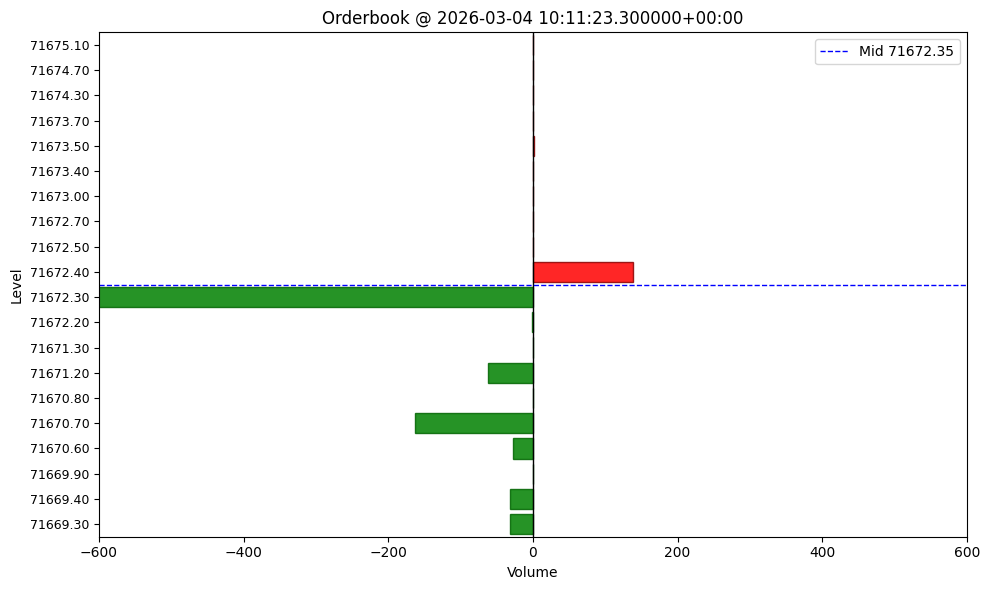

In [117]:
import numpy as np
import matplotlib.pyplot as plt

# Случайный момент времени
idx = np.random.randint(0, len(df))
row = df.iloc[idx]
print(f"Срез на момент: {row['ts_event']} (mid={row['mid_px']:.2f})")

# Сбор уровней bid/ask
BID_PX = [f"bid_px_{i:02d}" for i in range(1, 11)]
BID_SZ = [f"bid_sz_{i:02d}" for i in range(1, 11)]
ASK_PX = [f"ask_px_{i:02d}" for i in range(1, 11)]
ASK_SZ = [f"ask_sz_{i:02d}" for i in range(1, 11)]

bid_prices = np.array([row[c] for c in BID_PX], dtype=float)
bid_sizes = np.array([row[c] for c in BID_SZ], dtype=float)
ask_prices = np.array([row[c] for c in ASK_PX], dtype=float)
ask_sizes = np.array([row[c] for c in ASK_SZ], dtype=float)
bid_ok = ~np.isnan(bid_prices) & ~np.isnan(bid_sizes) & (bid_sizes > 0)
ask_ok = ~np.isnan(ask_prices) & ~np.isnan(ask_sizes) & (ask_sizes > 0)
bid_prices, bid_sizes = bid_prices[bid_ok], bid_sizes[bid_ok]
ask_prices, ask_sizes = ask_prices[ask_ok], ask_sizes[ask_ok]
bid_idx = np.argsort(-bid_prices)
ask_idx = np.argsort(ask_prices)
bid_prices, bid_sizes = bid_prices[bid_idx], bid_sizes[bid_idx]
ask_prices, ask_sizes = ask_prices[ask_idx], ask_sizes[ask_idx]

n_bid, n_ask = len(bid_prices), len(ask_prices)
y_bid = np.arange(n_bid)
y_ask = np.arange(n_bid, n_bid + n_ask)
bid_sizes_plot = bid_sizes[::-1]  # лучший bid вверху

fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlim(-600, 600)
bar_height = 0.8
ax.barh(y_bid, -bid_sizes_plot, color="green", alpha=0.85, height=bar_height, edgecolor="darkgreen")
ax.barh(y_ask, ask_sizes, color="red", alpha=0.85, height=bar_height, edgecolor="darkred")
ax.axvline(0, color="black", linewidth=1)
ax.axhline(n_bid - 0.5, color="blue", linewidth=1, linestyle="--", label=f"Mid {row['mid_px']:.2f}")
ax.set_xlabel("Volume")
ax.set_ylabel("Level")
yticks = list(y_bid) + list(y_ask)
ylabels = [f"{p:.2f}" for p in bid_prices[::-1]] + [f"{p:.2f}" for p in ask_prices]
ax.set_yticks(yticks)
ax.set_yticklabels(ylabels, fontsize=9)
ax.set_ylim(-0.5, n_bid + n_ask - 0.5)
ax.legend(loc="upper right")
ax.set_title(f"Orderbook @ {row['ts_event']}")
plt.tight_layout()
plt.show()

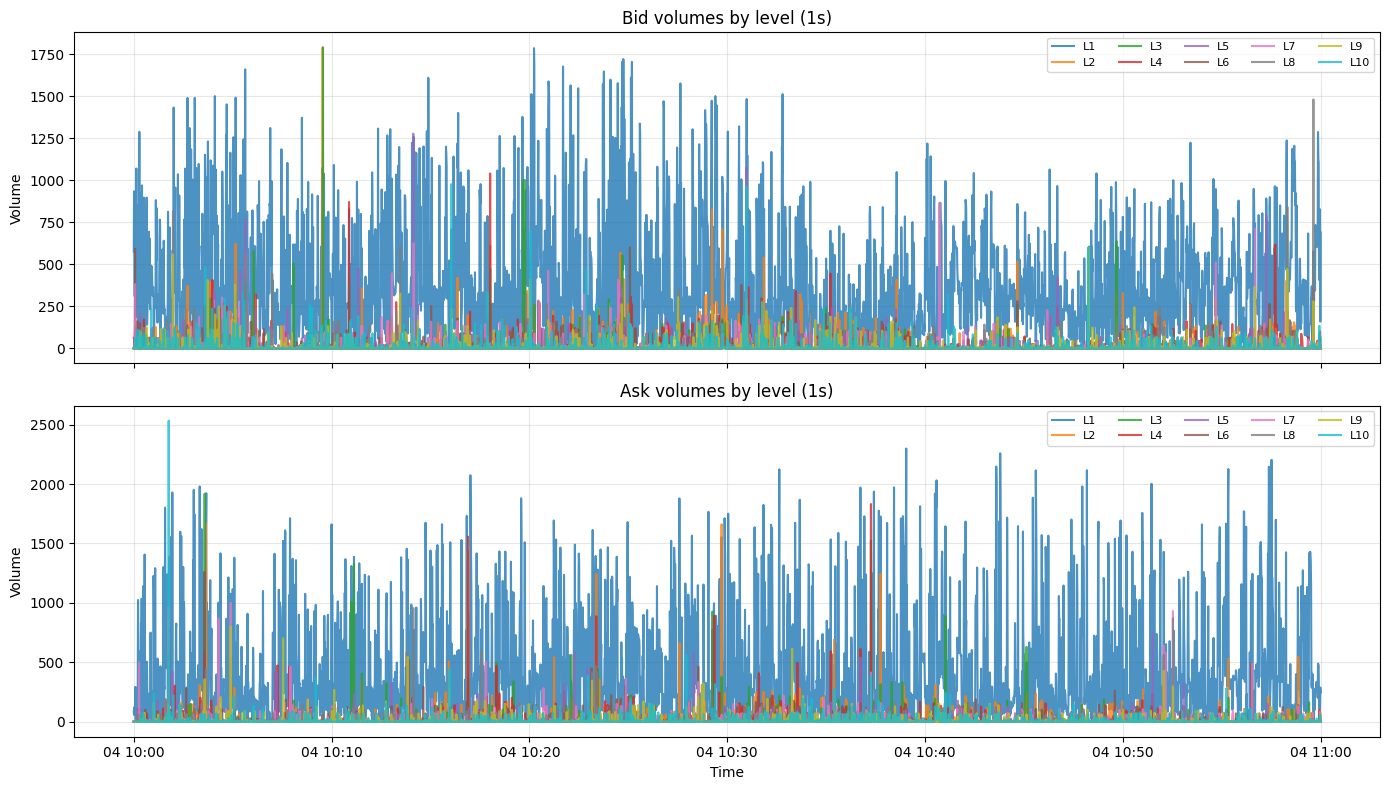

In [120]:
# Объёмы каждого уровня по времени, агрегация 1 с
agg = df.set_index("ts_event").resample("1s").last()

bid_cols = [f"bid_sz_{i:02d}" for i in range(1, 11)]
ask_cols = [f"ask_sz_{i:02d}" for i in range(1, 11)]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
for i, c in enumerate(bid_cols):
    ax1.plot(agg.index, agg[c], label=f"L{i+1}", alpha=0.8)
ax1.set_ylabel("Volume")
ax1.set_title("Bid volumes by level (1s)")
ax1.legend(loc="upper right", ncol=5, fontsize=8)
ax1.grid(True, alpha=0.3)

for i, c in enumerate(ask_cols):
    ax2.plot(agg.index, agg[c], label=f"L{i+1}", alpha=0.8)
ax2.set_ylabel("Volume")
ax2.set_xlabel("Time")
ax2.set_title("Ask volumes by level (1s)")
ax2.legend(loc="upper right", ncol=5, fontsize=8)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()